<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Korean_Exchange_Rate_News_Analysis_using_Naver_News_API_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Korean Exchange Rate News Analysis using Naver News API

Objective

- Collect Korean news articles using the Naver News API.
- Build a preprocessing pipeline for Korean news data.
- Compare keyword distributions across major news domains using TF-IDF.

In [1]:
import requests
import pandas as pd
import re
import html
import time
from urllib.parse import quote

In [3]:
query = "환율"

url = "https://openapi.naver.com/v1/search/news.json"

headers = {
    "X-Naver-Client-Id": client_id,
    "X-Naver-Client-Secret": client_secret
}

params = {
    "query": query,
    "display": 10,
    "start": 1,
    "sort": "date"
}

response = requests.get(
    url,
    headers=headers,
    params=params
)

data = response.json()
data

{'lastBuildDate': 'Sat, 27 Jun 2026 19:31:30 +0900',
 'total': 2374643,
 'start': 1,
 'display': 10,
 'items': [{'title': "주식 팔았는데 돈이 안 보인다?…초보 투자자의 단골 오해 '5가지'",
   'originallink': 'https://www.wikitree.co.kr/articles/1143531',
   'link': 'https://www.wikitree.co.kr/articles/1143531',
   'description': '실제 세금 계산은 <b>환율</b>, 수수료, 다른 해외 주식 손익, 신고 내용에 따라 달라질 수 있으므로 연말에 매매 내역을 확인해야 한다. 신고 시점도 놓치기 쉽다. 해외 주식 양도소득세는 일반적으로 다음 해 5월 신고·납부... ',
   'pubDate': 'Sat, 27 Jun 2026 18:14:00 +0900'},
  {'title': '폭염 예고에 올여름 여행 ‘가깝고 시원하게’…국내·근거리 주목',
   'originallink': 'https://www.ekn.kr/web/view.php?key=20260627025367082',
   'link': 'https://www.ekn.kr/web/view.php?key=20260627025367082',
   'description': '운임은 세금과 수수료가 포함된 6월 23일 <b>환율</b> 기준 금액으로, 실제 가격은 변동될 수 있다. 두 플랫폼 데이터는 올여름 여행 수요가 가깝고 시원하면서도 합리적인 쪽으로 향하고 있음을 보여준다. 다만 이는 각 사의... ',
   'pubDate': 'Sat, 27 Jun 2026 18:02:00 +0900'},
  {'title': '&quot;우리도 어쩔 수 없다&quot;는 애플의 가격 인상',
   'originallink': 'https://www.jnilbo.com/news/articleView.html

In [4]:
type(data)

dict

In [5]:
data.keys()

dict_keys(['lastBuildDate', 'total', 'start', 'display', 'items'])

In [6]:
data["items"][0]

{'title': "주식 팔았는데 돈이 안 보인다?…초보 투자자의 단골 오해 '5가지'",
 'originallink': 'https://www.wikitree.co.kr/articles/1143531',
 'link': 'https://www.wikitree.co.kr/articles/1143531',
 'description': '실제 세금 계산은 <b>환율</b>, 수수료, 다른 해외 주식 손익, 신고 내용에 따라 달라질 수 있으므로 연말에 매매 내역을 확인해야 한다. 신고 시점도 놓치기 쉽다. 해외 주식 양도소득세는 일반적으로 다음 해 5월 신고·납부... ',
 'pubDate': 'Sat, 27 Jun 2026 18:14:00 +0900'}

In [7]:
query = "환율"

all_items = []

for start in range(1, 101, 10):
    params = {
        "query": query,
        "display": 10,
        "start": start,
        "sort": "date"
    }

    response = requests.get(
        url,
        headers=headers,
        params=params
    )

    data = response.json()
    items = data.get("items", [])

    all_items.extend(items)

    time.sleep(0.3)

In [8]:
len(all_items)

100

In [9]:
df = pd.DataFrame(all_items)

df.head()

,title,originallink,link,description,pubDate
0,주식 팔았는데 돈이 안 보인다?…초보 투자자의 단골 오해 '5가지',https://www.wikitree.co.kr/articles/1143531,https://www.wikitree.co.kr/articles/1143531,"실제 세금 계산은 <b>환율</b>, 수수료, 다른 해외 주식 손익, 신고 내용에 ...","Sat, 27 Jun 2026 18:14:00 +0900"
1,폭염 예고에 올여름 여행 ‘가깝고 시원하게’…국내·근거리 주목,https://www.ekn.kr/web/view.php?key=2026062702...,https://www.ekn.kr/web/view.php?key=2026062702...,"운임은 세금과 수수료가 포함된 6월 23일 <b>환율</b> 기준 금액으로, 실제 ...","Sat, 27 Jun 2026 18:02:00 +0900"
2,&quot;우리도 어쩔 수 없다&quot;는 애플의 가격 인상,https://www.jnilbo.com/news/articleView.html?i...,https://www.jnilbo.com/news/articleView.html?i...,원/달러 <b>환율</b>까지 겹친 결과다. 국내 기준 인상률은 맥북이 약 15~2...,"Sat, 27 Jun 2026 17:27:00 +0900"
3,삼전닉스 역대급 실적으로 외화 벌어와도 소용없네…치솟는 <b>환율</b> 어디까...,https://view.asiae.co.kr/article/2026062516414...,https://n.news.naver.com/mnews/article/277/000...,원·달러 <b>환율</b>은 내려가는 게 자연스럽다. 그런데 요즘 외환시장은 교과서...,"Sat, 27 Jun 2026 17:23:00 +0900"
4,"CPTPP, 수면 위로···농업계 '검역변수' 촉각",http://www.newsfarm.co.kr/news/articleView.htm...,http://www.newsfarm.co.kr/news/articleView.htm...,"이 수치는 당시 기준으로의 추산인 만큼 영국 합류, 최근 <b>환율</b>·수입가격...","Sat, 27 Jun 2026 16:40:00 +0900"


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         100 non-null    object
 1   originallink  100 non-null    object
 2   link          100 non-null    object
 3   description   100 non-null    object
 4   pubDate       100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [11]:
df.columns

Index(['title', 'originallink', 'link', 'description', 'pubDate'], dtype='object')

#■전처리

## HTML 태그 제거

In [12]:
def clean_html(text):
    text = html.unescape(text)
    text = re.sub(r"<.*?>", "", text)
    return text

In [13]:
df["title_clean"] = df["title"].apply(clean_html)
df["description_clean"] = df["description"].apply(clean_html)

df.head()

,title,originallink,link,description,pubDate,title_clean,description_clean
0,주식 팔았는데 돈이 안 보인다?…초보 투자자의 단골 오해 '5가지',https://www.wikitree.co.kr/articles/1143531,https://www.wikitree.co.kr/articles/1143531,"실제 세금 계산은 <b>환율</b>, 수수료, 다른 해외 주식 손익, 신고 내용에 ...","Sat, 27 Jun 2026 18:14:00 +0900",주식 팔았는데 돈이 안 보인다?…초보 투자자의 단골 오해 '5가지',"실제 세금 계산은 환율, 수수료, 다른 해외 주식 손익, 신고 내용에 따라 달라질 ..."
1,폭염 예고에 올여름 여행 ‘가깝고 시원하게’…국내·근거리 주목,https://www.ekn.kr/web/view.php?key=2026062702...,https://www.ekn.kr/web/view.php?key=2026062702...,"운임은 세금과 수수료가 포함된 6월 23일 <b>환율</b> 기준 금액으로, 실제 ...","Sat, 27 Jun 2026 18:02:00 +0900",폭염 예고에 올여름 여행 ‘가깝고 시원하게’…국내·근거리 주목,"운임은 세금과 수수료가 포함된 6월 23일 환율 기준 금액으로, 실제 가격은 변동될..."
2,&quot;우리도 어쩔 수 없다&quot;는 애플의 가격 인상,https://www.jnilbo.com/news/articleView.html?i...,https://www.jnilbo.com/news/articleView.html?i...,원/달러 <b>환율</b>까지 겹친 결과다. 국내 기준 인상률은 맥북이 약 15~2...,"Sat, 27 Jun 2026 17:27:00 +0900","""우리도 어쩔 수 없다""는 애플의 가격 인상","원/달러 환율까지 겹친 결과다. 국내 기준 인상률은 맥북이 약 15~20%, 아이패..."
3,삼전닉스 역대급 실적으로 외화 벌어와도 소용없네…치솟는 <b>환율</b> 어디까...,https://view.asiae.co.kr/article/2026062516414...,https://n.news.naver.com/mnews/article/277/000...,원·달러 <b>환율</b>은 내려가는 게 자연스럽다. 그런데 요즘 외환시장은 교과서...,"Sat, 27 Jun 2026 17:23:00 +0900",삼전닉스 역대급 실적으로 외화 벌어와도 소용없네…치솟는 환율 어디까...,원·달러 환율은 내려가는 게 자연스럽다. 그런데 요즘 외환시장은 교과서대로 움직이지...
4,"CPTPP, 수면 위로···농업계 '검역변수' 촉각",http://www.newsfarm.co.kr/news/articleView.htm...,http://www.newsfarm.co.kr/news/articleView.htm...,"이 수치는 당시 기준으로의 추산인 만큼 영국 합류, 최근 <b>환율</b>·수입가격...","Sat, 27 Jun 2026 16:40:00 +0900","CPTPP, 수면 위로···농업계 '검역변수' 촉각","이 수치는 당시 기준으로의 추산인 만큼 영국 합류, 최근 환율·수입가격, 국내 생산..."


## 날짜처리

In [14]:
df["pubDate"] = pd.to_datetime(df["pubDate"])
df["date"] = df["pubDate"].dt.date
df["year"] = df["pubDate"].dt.year
df["month"] = df["pubDate"].dt.to_period("M")

df[["pubDate", "date", "month"]].head()

/tmp/ipykernel_16995/2149661944.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["pubDate"].dt.to_period("M")


,pubDate,date,month
0,2026-06-27 18:14:00+09:00,2026-06-27,2026-06
1,2026-06-27 18:02:00+09:00,2026-06-27,2026-06
2,2026-06-27 17:27:00+09:00,2026-06-27,2026-06
3,2026-06-27 17:23:00+09:00,2026-06-27,2026-06
4,2026-06-27 16:40:00+09:00,2026-06-27,2026-06


## 언론사 추출

In [15]:
from urllib.parse import urlparse

def extract_domain(url):
    if pd.isna(url):
        return None
    try:
        return urlparse(url).netloc
    except:
        return None

df["domain"] = df["originallink"].apply(extract_domain)

In [16]:
df["domain"].value_counts()

,count
domain,
news.einfomax.co.kr,7
www.tokenpost.kr,6
www.newsis.com,5
www.pinpointnews.co.kr,4
www.donga.com,4
...,...
www.breaknews.com,1
www.wikileaks-kr.org,1
www.choicenews.co.kr,1


##중복제거

In [17]:
df = df.drop_duplicates(
    subset = ["title_clean", "originallink"]
).reset_index(drop=True)

In [18]:
df.shape

(100, 11)

## 분석용 텍스트

In [19]:
df["text"] = (
    df["title_clean"].fillna("") + " " +
    df["description_clean"].fillna("")
)

#■ 기본 EDA

In [22]:
df["domain"].value_counts().head(20)

,count
domain,
news.einfomax.co.kr,7
www.tokenpost.kr,6
www.newsis.com,5
www.pinpointnews.co.kr,4
www.donga.com,4
www.wikitree.co.kr,3
www.sedaily.com,3
www.joongang.co.kr,3
www.joongangenews.com,2


<Axes: title={'center': 'Top News Domains'}, ylabel='domain'>

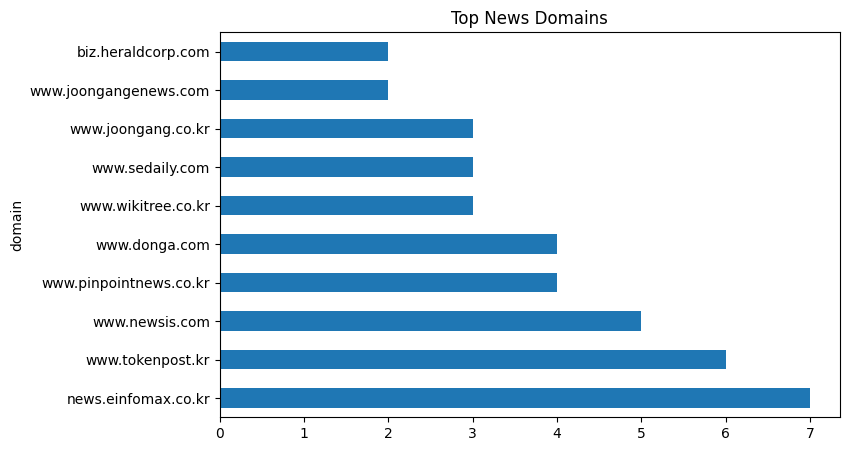

In [25]:
df["domain"].value_counts().head(10).plot(
    kind = "barh",
    figsize = (8,5),
    title = "Top News Domains"
    )

In [26]:
df.columns

Index(['title', 'originallink', 'link', 'description', 'pubDate',
       'title_clean', 'description_clean', 'date', 'year', 'month', 'domain',
       'text'],
      dtype='object')

In [30]:
top_domains = df["domain"].value_counts().head(5).index
    #index(첫번째 열 = domain)만 뽑아옴

df_top = df[df["domain"].isin(top_domains)].copy()

In [31]:
df_top["domain"].value_counts()

,count
domain,
news.einfomax.co.kr,7
www.tokenpost.kr,6
www.newsis.com,5
www.pinpointnews.co.kr,4
www.donga.com,4


#한국어 전처리

In [34]:
def clean_korean_text(text):
    text = str(text)
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df_top["text_clean"] = df_top["text"].apply(clean_korean_text)

#■ 분석

##CountVectorizer

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    min_df = 2,
    max_df = 0.8
)

X = vectorizer.fit_transform(df_top["text_clean"])

words = vectorizer.get_feature_names_out()

In [36]:
word_counts = X.sum(axis=0)
word_counts = word_counts.A1
word_df = pd.DataFrame({
    "word" : words,
    "count" : word_counts
})

word_df.sort_values(
    "count",
    ascending = False
).head(30)

,word,count
36,달러,37
100,환율,16
103,환율이,15
101,환율은,14
78,있다,7
7,161,6
14,6월,6
93,투자,5
43,미국,4
49,상승,4


In [39]:
domain_name = df_top["domain"].value_counts().index[0]
# 가장 기사 수가 많은 도메인의 주요단어 보기

domain_texts = df_top.loc[
    df_top["domain"] == domain_name,
    "text_clean"
]

In [40]:
X_domain = vectorizer.transform(domain_texts)
domain_counts = X_domain.sum(axis=0).A1

domain_word_df = pd.DataFrame({
    "word" : words,
    "count" : domain_counts
})

domain_word_df.sort_values(
    "count",
    ascending=False
).head(30)

,word,count
36,달러,20
101,환율은,8
100,환율,5
7,161,4
58,연합인포맥스,3
71,유로,3
4,13870달러로,2
0,00144달러,2
39,따르면,2
32,내주,2


## TF-IDF

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf_vectorizer = TfidfVectorizer(
    min_df = 2,
    max_df = 0.8,
    ngram_range = (1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(df_top["text_clean"])

tfidf_words = tfidf_vectorizer.get_feature_names_out()

In [46]:
domain_name = df_top["domain"].value_counts().index[0]

domain_idx = df_top["domain"] == domain_name

X_domain = X_tfidf[domain_idx.to_numpy()]

mean_scores = np.asarray(
    X_domain.mean(axis = 0)
).flatten()

domain_tfidf_df = pd.DataFrame({
    "word" : tfidf_words,
    "score" : mean_scores
    })

domain_tfidf_df.sort_values(
    "score",
    ascending = False
).head(30)

,word,score
55,달러,0.317384
142,환율은,0.159775
58,달러 환율은,0.126413
141,환율,0.114606
87,연합인포맥스,0.108203
57,달러 환율,0.106759
86,연준,0.088592
19,4분기,0.088592
18,490원,0.088592
13,161,0.087206


##도메인별 TF-IDF 자동반복

In [48]:
tfidf_by_domain = {}

for domain in top_domains:
    domain_idx = df_top["domain"] == domain

    X_domain = X_tfidf[domain_idx.to_numpy()]

    mean_scores = np.asarray(
        X_domain.mean(axis=0)
    ).flatten()

    temp_df = pd.DataFrame({
        "word" : tfidf_words,
        "score" : mean_scores
    }).sort_values(
        "score",
        ascending = False
    ).head(30)

    tfidf_by_domain[domain] = temp_df

In [50]:
tfidf_by_domain[top_domains[0]]

,word,score
55,달러,0.317384
142,환율은,0.159775
58,달러 환율은,0.126413
141,환율,0.114606
87,연합인포맥스,0.108203
57,달러 환율,0.106759
86,연준,0.088592
19,4분기,0.088592
18,490원,0.088592
13,161,0.087206


In [52]:
top_words_table = pd.DataFrame({
    domain : tfidf_by_domain[domain]["word"].to_numpy()
    for domain in top_domains
})

top_words_table.head(30)

,news.einfomax.co.kr,www.tokenpost.kr,www.newsis.com,www.pinpointnews.co.kr,www.donga.com
0,달러,달러,미국,실적,환율이
1,환율은,환율은,시장,메모리,하지만
2,달러 환율은,달러 환율이,전문가가,사상,150원
3,환율,환율이,있다,환율,1500원대
4,연합인포맥스,전통,투자,투자,외국인의
5,달러 환율,외환시장,환율이,최근,있다
6,연준,서울 외환시장에서,환율,기대,따른
7,4분기,경제,이날,크게,고공행진을 이어가고
8,490원,경기,sk하이닉스,ai,고공행진을
9,161,내린,코스피,확대와,이어가고


In [54]:
df_top.loc[
    df_top["domain"] == domain_name,
    ["title_clean", "description_clean"]
]

,title_clean,description_clean
49,"NDF, 1,535.70/ 1,536.10원…4.45원↑","언급하며 ""휴전 협정의 어리석은 위반이 명백하다""고 지적했다. 달러 인덱스 종가는 ..."
56,"부산銀 ""달러-원, 하반기 오버슈팅 점진적 해소…4분기 1,490원 전망""","달러-원과 한국경제성장률 비교 추이(왼쪽), 분기별 달러-원 레인지BNK부산은행 B..."
59,[뉴욕마켓워치] 유가 넉달만에 70달러 밑으로…주식·달러↓채권 혼조,◇외환시장 연합인포맥스(화면번호 6411)에 따르면 오후 4시 현재 뉴욕 외환시장에...
66,"""유가 하락에 인플레 압력↓…연준 인상 우려 완화 시 약달러 재현""","3분기와 4분기 평균 환율은 각각 1,490원, 1,430원으로 예상했다. 민 이코..."
67,[뉴욕환시] 달러 이틀째↓…사우디 원유 공급 정상화 가능성,"달러-엔 환율은 161.758엔으로, 전장 뉴욕장 마감 가격 161.792엔보다 0..."
69,"유가는 되돌렸는데 달러는 강세…환율, 결국 금리의 문제",상반기 달러-원 환율을 끌어올렸던 지정학적 리스크가 완화됐으나 시장의 관심은 다시 ...
79,"달러-원, 안전 선호 확산에 낙폭 축소…1,535.80원 마감",달러-원 환율 일중 추이[출처 : 연합인포맥스] 진정호 연합인포맥스 특파원 = 달러...


Findings

- Successfully built an end-to-end workflow from API collection to keyword analysis.
- Compared TF-IDF keywords across news domains.
- No clear domain-specific framing patterns were observed in this dataset.